#### Exploratory Data Analysis

The goal of the notebook is to understand the cleaned resume corpus deeply. We look at Length distributions (tokens/chars), section coverage, vocabulary patterns (unigrams/bigrams), and a qualitative word-cloud.

EDA is important because it highlights outliers, supports filtering thresholds, and surfaces domain language that drives TF-IDF/embedding behaviour.

In [44]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [46]:
import os, json, math, re
from pathlib import Path
from collections import Counter
from typing import List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer

try:
    import pyarrow
    _PARQUET_OK = True
except Exception:
    _PARQUET_OK = False

try:
    from sklearn.feature_extraction.text import CountVectorizer
    _SKLEARN_OK = True
except Exception:
    _SKLEARN_OK = False

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Project Folders
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT/"data"
RAW_DIR = DATA_DIR/"raw"
PROCESSED_DIR = DATA_DIR/"processed"
MODELS_DIR = PROJECT_ROOT/"models"
FIGURES_DIR = PROJECT_ROOT/"figures"
ARTIFACTS_DIR = PROJECT_ROOT/"artifacts"
LOGS_DIR = PROJECT_ROOT/"logs"
REPORTS_DIR = PROJECT_ROOT/"reports"

for d in [DATA_DIR, RAW_DIR, PROCESSED_DIR, MODELS_DIR, FIGURES_DIR, ARTIFACTS_DIR, LOGS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLEAN_PARQUET = DATA_DIR/"processed"/"resumes_clean.parquet"
CLEAN_CSV = DATA_DIR/"processed"/"resumes_clean.csv"
TEXT_COL = "clean_text_redacted"

In [5]:
def load_cleaned() -> pd.DataFrame:
    if CLEAN_PARQUET.exists():
        return pd.read_parquet(CLEAN_PARQUET)
    elif CLEAN_CSV.exists():
        return pd.read_csv(CLEAN_CSV)
    else:
        raise FileNotFoundError("Cleaned data not found in 'data/processed/'.")

df = load_cleaned()
print(df.shape)
df.head()

(31647, 11)


,row_id,raw_text,label,clean_text,clean_text_redacted,n_chars,n_tokens,has_skills,has_education,has_experience,skills_block
0,0,ACCOUNTANT Professional Summary Results orient...,None,ACCOUNTANT Professional Summary Results orient...,ACCOUNTANT Professional Summary Results orient...,5519,746,True,True,True,
1,1,STAFF ACCOUNTANT Summary Flexible Accountant w...,None,STAFF ACCOUNTANT Summary Flexible Accountant w...,STAFF ACCOUNTANT Summary Flexible Accountant w...,8776,1226,True,True,True,
2,2,STAFF ACCOUNTANT Summary Highly analytical and...,None,STAFF ACCOUNTANT Summary Highly analytical and...,STAFF ACCOUNTANT Summary Highly analytical and...,7265,1051,True,True,True,
3,3,SENIOR ACCOUNTANT Summary A highly competent m...,None,SENIOR ACCOUNTANT Summary A highly competent m...,SENIOR ACCOUNTANT Summary A highly competent m...,4812,659,True,True,True,
4,4,SENIOR ACCOUNTANT Summary 11 years experience ...,None,SENIOR ACCOUNTANT Summary 11 years experience ...,SENIOR ACCOUNTANT Summary 11 years experience ...,4776,673,True,True,True,


#### Basic Overview

In [7]:
print('Columns:', list(df.columns))
print('\nNull fraction per column:')
display(df.isna().mean().sort_values(ascending=False).head(20))

desc_cols = [c for c in ['n_tokens', 'n_chars'] if c in df.columns]
if desc_cols:
    display(df[desc_cols].describe().T)
print('nSample rows:')
display(df[[TEXT_COL]].head())

Columns: ['row_id', 'raw_text', 'label', 'clean_text', 'clean_text_redacted', 'n_chars', 'n_tokens', 'has_skills', 'has_education', 'has_experience', 'skills_block']

Null fraction per column:


label                  1.0
row_id                 0.0
raw_text               0.0
clean_text             0.0
clean_text_redacted    0.0
n_chars                0.0
n_tokens               0.0
has_skills             0.0
has_education          0.0
has_experience         0.0
skills_block           0.0
dtype: float64

,count,mean,std,min,25%,50%,75%,max
n_tokens,31647.0,913.881063,757.922785,20.0,394.0,673.0,1155.0,12604.0
n_chars,31647.0,6388.645906,5207.118704,154.0,2780.0,4787.0,8127.0,83694.0


nSample rows:


,clean_text_redacted
0,ACCOUNTANT Professional Summary Results orient...
1,STAFF ACCOUNTANT Summary Flexible Accountant w...
2,STAFF ACCOUNTANT Summary Highly analytical and...
3,SENIOR ACCOUNTANT Summary A highly competent m...
4,SENIOR ACCOUNTANT Summary 11 years experience ...


#### Length Distributions - Token Count Distribution

The **Token Count Distribution** shows how long resumes are in words after cleaning/redaction.

In [11]:
PALETTE = {
    "blue":  "#4e79a7",
    "green": "#59a14f",
    "orange":"#f28e2b",
    "red":   "#e15759",
    "purple":"#b07aa1",
    "teal":  "#76b7b2",
    "gray":  "#9c9c9c",
}

def pretty_ax(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, pad=12, fontsize=14, weight="bold")
    if xlabel:
        ax.set_xlabel(xlabel, labelpad=8)
    if ylabel:
        ax.set_ylabel(ylabel, labelpad=8)
    ax.grid(True, axis="y", alpha=0.25)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    return ax

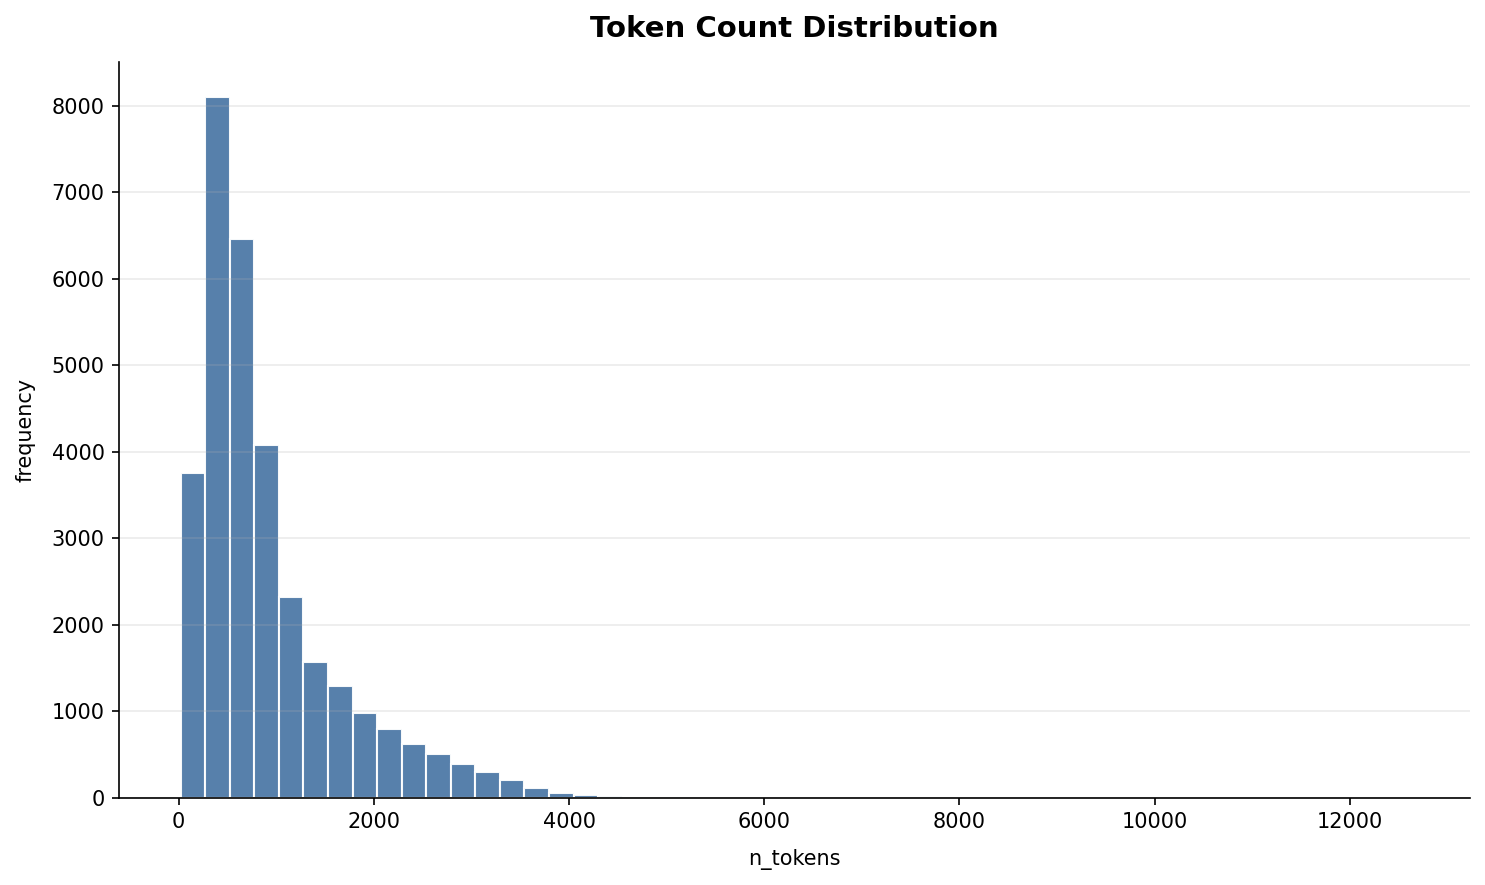

Saved: C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\figures\eda_tokens_hist.png


In [25]:
# Token histogram
vals = df["n_tokens"].values
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.hist(vals, bins=50, color=PALETTE["blue"], edgecolor="white", alpha=0.95)
pretty_ax(ax, "Token Count Distribution", "n_tokens", "frequency")
out = FIGURES_DIR/'eda_tokens_hist.png'
plt.tight_layout()
plt.savefig(out, bbox_inches='tight', dpi=150)
plt.show()
print('Saved:', out)

##### Key Takeaways

The distribution is **heavily right-skewed**, most number of resumes are short/medium in length. Few are very long (>10k tokens).

#### Length Distributions - Character Count Distribution

The **Character Count Distribution** shows character-level, length

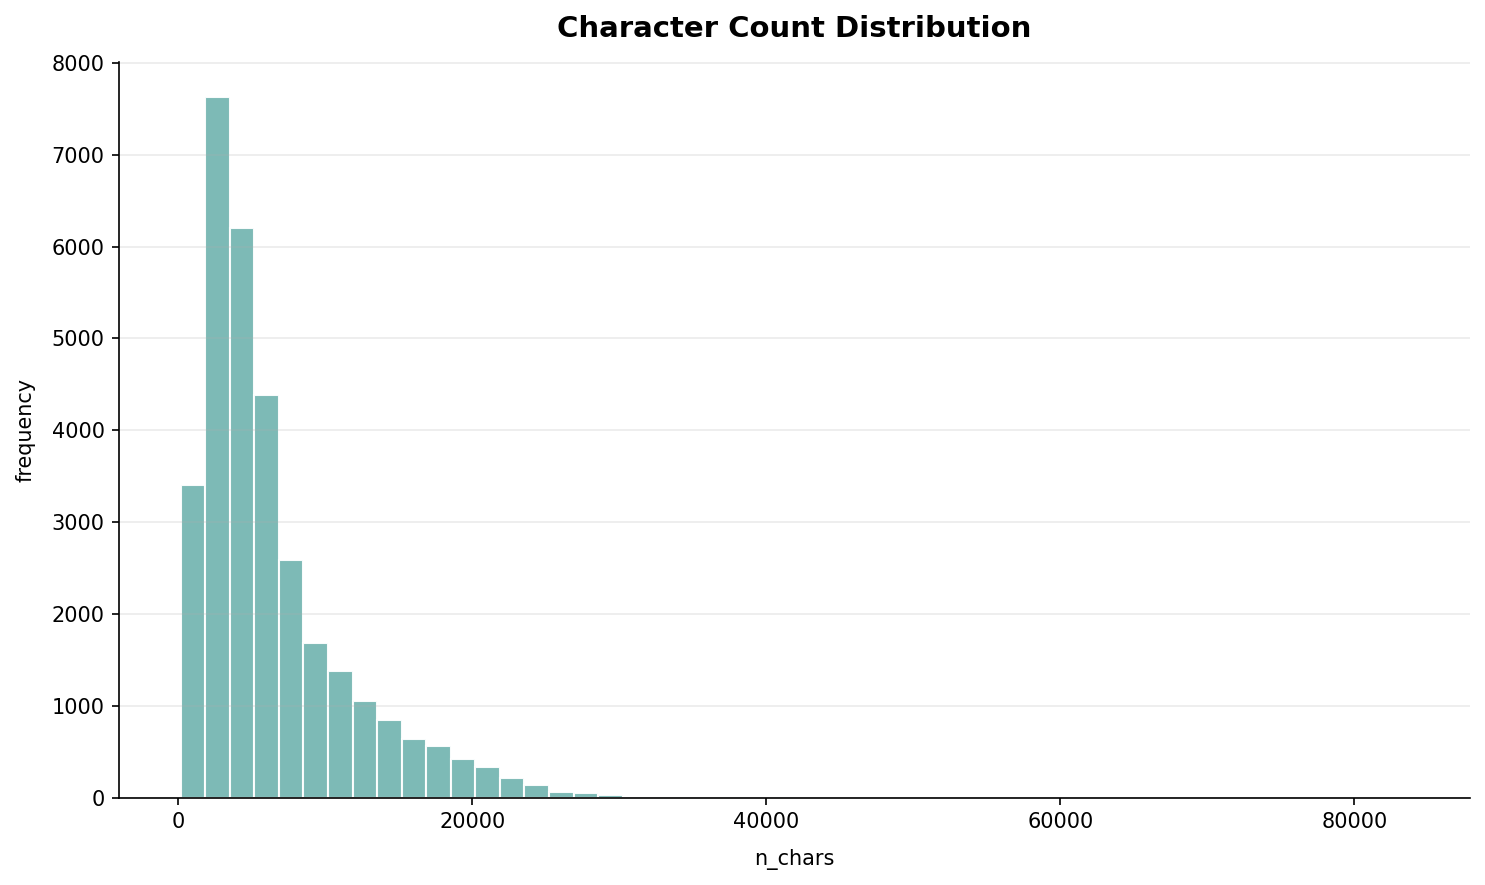

Saved: C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\figures\eda_chars_hist.png


In [27]:
# Character histogram
# Token histogram
vals = df["n_chars"].values
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.hist(vals, bins=50, color=PALETTE["teal"], edgecolor="white", alpha=0.95)
pretty_ax(ax, "Character Count Distribution", "n_chars", "frequency")
out = FIGURES_DIR/'eda_chars_hist.png'
plt.tight_layout()
plt.savefig(out, bbox_inches='tight', dpi=150)
plt.show()
print('Saved:', out)

##### Key TakeawaysThis distribution is also **right-skewed** with a small number of resumes having >80000 characters. Small number of resumes are abnormally long.


#### Section Coverage

This shows the **fraction of resumes** that contain section cues, "Skills", "Education" and "Experience" sections.

has_skills        0.913925
has_education     0.946377
has_experience    0.994660
Name: fraction_present, dtype: float64

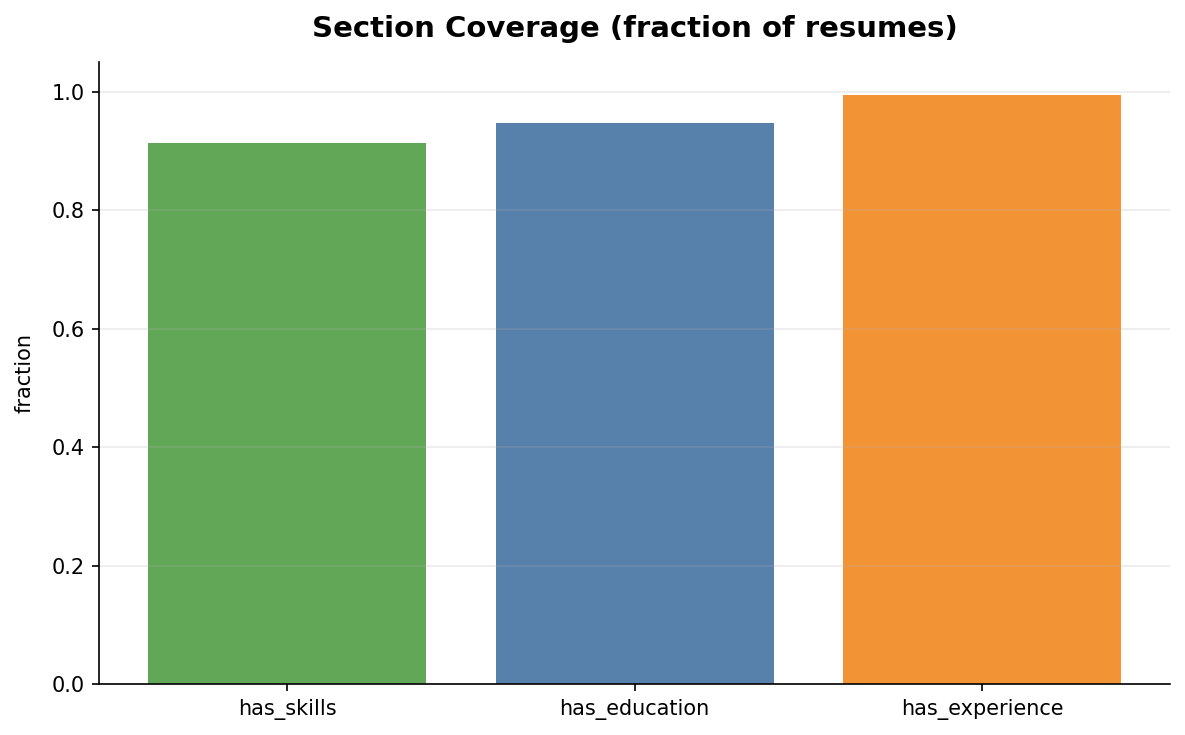

Saved: C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\figures\eda_section_coverage.png


In [37]:
flags = [c for c in ['has_skills', 'has_education', 'has_experience'] if c in df.columns]
if flags:
    frac = pd.Series({c: float(df[c].mean()) for c in flags}, name='fraction_present')
    display(frac)

    fig, ax = plt.subplots(figsize=(8,5), dpi=150)
    ax.bar(frac.index.tolist(), frac.values.tolist(), color=[PALETTE["green"], PALETTE["blue"], PALETTE["orange"]], alpha=0.95)
    ax.set_ylim(0, 1.05)
    pretty_ax(ax, "Section Coverage (fraction of resumes)", "", "fraction")
    out = FIGURES_DIR/'eda_section_coverage.png'
    plt.tight_layout()
    plt.savefig(out, bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved:', out)
else:
    print('No section flags found (has_skills/ has_education/ has_experience).')

##### Key Takeaways
There are **high coverage** for all the three sections (~0.9-1.0 fractions). Most resumes explicitly mention these headers. "Experience" appears most consistently.

#### Skills Summary from skills_block

Parses skills_block (if present), splits on separators, and shows frequent items.

,skill,count
0,work,306
1,authorized to work in the us for any employer ...,182
2,and,166
3,extensive,28
4,and proven,27
5,sponsorship required to work in the us work,19
6,handson,16
7,and a highly motivated team player with the ab...,16
8,in development of effective userfriendly web a...,15
9,user,14


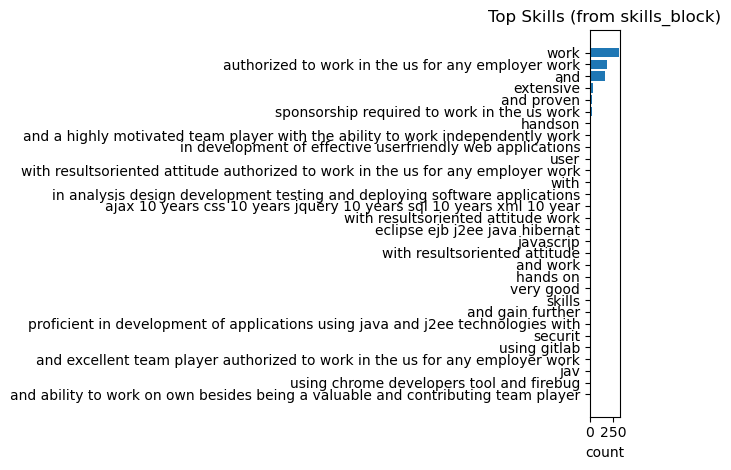

Saved: C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\figures\eda_top_skills.png


In [14]:
def explode_skills(block: str) -> List[str]:
    if not isinstance(block, str) or not block.strip():
        return []
    parts = re.split(r'[;\n\|,]', block)
    parts = [p.strip() for p in parts if p.strip()]
    return parts

skills = []
if 'skills_block' in df.columns:
    for s in df['skills_block'].astype(str).tolist():
        skills.extend(explode_skills(s))

if skills:
    cnt = Counter([s.lower() for s in skills])
    top_skills = pd.DataFrame(cnt.most_common(30), columns=['skill', 'count'])
    display(top_skills)

    plt.figure()
    plt.barh(top_skills['skill'].tolist()[::-1], top_skills['count'].tolist()[::-1])
    plt.title('Top Skills (from skills_block)')
    plt.xlabel('count')
    out = FIGURES_DIR/'eda_top_skills.png'
    plt.tight_layout()
    plt.savefig(out, bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved:', out)
else:
    print('No skills_block column or it is empty.')

#### Top N-grams (Unigrams & Bigrams)

Extracts frequent terms from clean_text_redacted using CountVectorizer (English stop-words). Saves top terms to CSV in reports/ and plots the top 30 for each.

,term,count
0,using,267981
1,data,180495
2,web,165905
3,experience,134876
4,application,127817
5,management,123051
6,development,120844
7,used,116190
8,developed,113689
9,database,111183


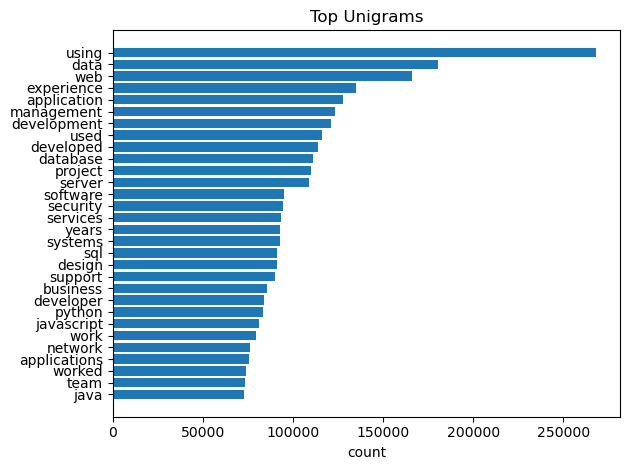

Saved: C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\figures\eda_top_unigrams.png


,term,count
0,web services,36354
1,sql server,35287
2,work experience,30113
3,html css,19846
4,using python,17006
5,active directory,16773
6,10 years,16725
7,additional information,16022
8,web application,14739
9,javascript jquery,14113


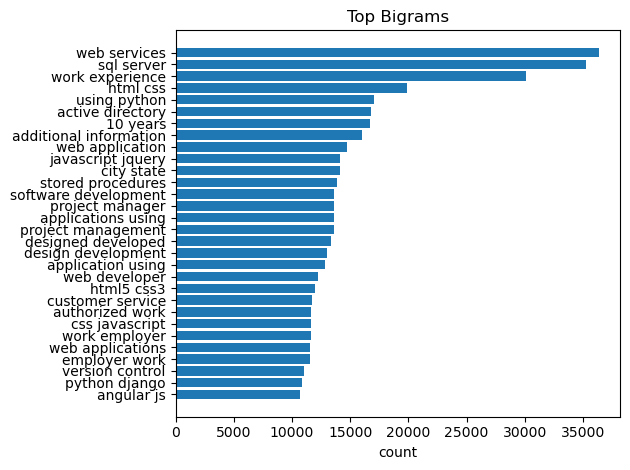

Saved: C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\figures\eda_top_bigrams.png


In [16]:
def top_ngrams(texts: List[str], ngram_range=(1, 1), min_df=5, max_features=50000, top_k=30) -> pd.DataFrame:
    if not _SKLEARN_OK:
        raise ImportError('scikit-learn not available. Install it to run n-gram analysis.')
    cv = CountVectorizer(stop_words='english', ngram_range=ngram_range, min_df=min_df, max_features=max_features)
    X = cv.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(cv.get_feature_names_out())
    idx = np.argsort(freqs)[::-1][:top_k]
    return pd.DataFrame({'term': terms[idx], 'count': freqs[idx]})

texts = df[TEXT_COL].astype(str).tolist()

try:
    top_uni = top_ngrams(texts, (1, 1), min_df=5, top_k=30)
    display(top_uni)

    plt.figure()
    plt.barh(top_uni['term'].tolist()[::-1], top_uni['count'].tolist()[::-1])
    plt.title('Top Unigrams')
    plt.xlabel('count')
    out = FIGURES_DIR/'eda_top_unigrams.png'
    plt.tight_layout()
    plt.savefig(out, bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved:', out)

    top_bi = top_ngrams(texts, (2, 2), min_df=5, top_k=30)
    display(top_bi)

    plt.figure()
    plt.barh(top_bi['term'].tolist()[::-1], top_bi['count'].tolist()[::-1])
    plt.title('Top Bigrams')
    plt.xlabel('count')
    out = FIGURES_DIR/'eda_top_bigrams.png'
    plt.tight_layout()
    plt.savefig(out, bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved:', out)

    top_uni.to_csv(REPORTS_DIR/'eda_top_unigrams.csv', index=False)
    top_bi.to_csv(REPORTS_DIR/'eda_top_bigrams.csv', index=False)
except Exception as e:
    print('Skipping n-gram analysis:', e)

##### Key Takeaways

The top Unigrams are core technical/role terms like **data**, **web**, **aplications** etc.

The top Bigrams are also technical related. 

#### Label Distribution

Shows frequency of labels if a label column exists with values.

In [18]:
if 'label' in df.columns and df['label'].notna().any():
    vc = df['label'].value_counts(dropna=True).head(30)
    display(vc)

    plt.figure()
    plt.barh(vc.index.tolist()[::-1], vc.values.tolist()[::-1])
    plt.title('Label Distribution (top 30)')
    plt.xlabel('count')
    out = FIGURES_DIR/'eda_label_distribution.png'
    plt.tight_layout()
    plt.savefig(out, bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved:', out)
else:
    print('No non-empty label column found; skipping label distribution.')

No non-empty label column found; skipping label distribution.


#### Outlier Tables (Shortest & Longest by Tokens)

Review the extremes to validate thresholds.

In [20]:
if 'n_tokens' in df.columns:
    shortest = df.nsmallest(10, 'n_tokens')[['n_tokens', TEXT_COL]].copy()
    longest = df.nlargest(10, 'n_tokens')[['n_tokens', TEXT_COL]].copy()
    display(shortest)
    display(longest)
    shortest.to_csv(REPORTS_DIR/'eda_shortest_by_tokens.csv', index=False)
    longest.to_csv(REPORTS_DIR/'eda_longest_by_tokens.csv', index=False)
    print('Saved shortest/longest tables to reports/.')
else:
    print('n_tokens not found; skipping outlier tables.')

,n_tokens,clean_text_redacted
118,20,Education Details LLB Dibrugarh University Adv...
9899,20,Network Administrator span lNetworkspan span l...
24645,20,Systems Administrator span lSystemsspan span l...
26142,20,Systems Administrator span lSystemsspan span l...
29677,20,Systems Administrator span lSystemsspan span l...
4703,21,Education Details BA mumbai University HR Skil...
5982,21,Network Administrator span lNetworkspan span l...
12183,21,Network Administrator span lNetworkspan span l...
22510,21,Systems Administrator span lSystemsspan span l...
23865,21,Software Developer span lSoftwarespan span lDe...


,n_tokens,clean_text_redacted
30680,12604,Job Seeker I have been working as a hands on s...
2170,8839,IT Specialist span lITspan Specialist IT Speci...
1671,6825,Technical Lead for Software Project Technical ...
8008,6304,C VBNET SQL Server ERWin API Developer C VBNET...
11109,6061,UIUX Lead Developer UIUX Lead span lDevelopers...
27507,6035,Sr Python Developer Sr span lPythonspan span l...
15415,5919,Senior JavaRESTful Developer Senior span lJava...
17080,5779,SQL Server DBA Apple iPhoneiPad Visual StudioC...
6462,5678,Full Stack Net Developer Full Stack Net span l...
2957,5487,SystemsNetwork Administrator SystemsNetwork En...


Saved shortest/longest tables to reports/.


In [48]:
EXTRA_STOPS = {
    "experience","responsible","responsibilities","role","roles","skills","team","work","working",
    "excellent","strong","good","knowledge","ability","communication","customer","support",
    "requirements","duties","tasks","year","years","project","projects","company","job","jobs",
    "apply","candidate","please","required","preferred"
}
WC_STOPS = STOPWORDS | EXTRA_STOPS

def tfidf_unigram_weights(texts, min_df=3, max_df=0.95, max_features=30000):
    vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 1), min_df=min_df,
                          max_df=max_df, max_features=max_features, strip_accents="unicode",
                          sublinear_tf=True)
    X = vec.fit_transform(texts)
    weights = np.asarray(X.sum(axis=0)).ravel()
    vocab = vec.get_feature_names_out()
    freqs = {t: float(w) for t, w in zip(vocab, weights)}
    # for readability, only top N are taken
    return dict(sorted(freqs.items(), key=lambda kv: kv[1], reverse=True)[:1000])

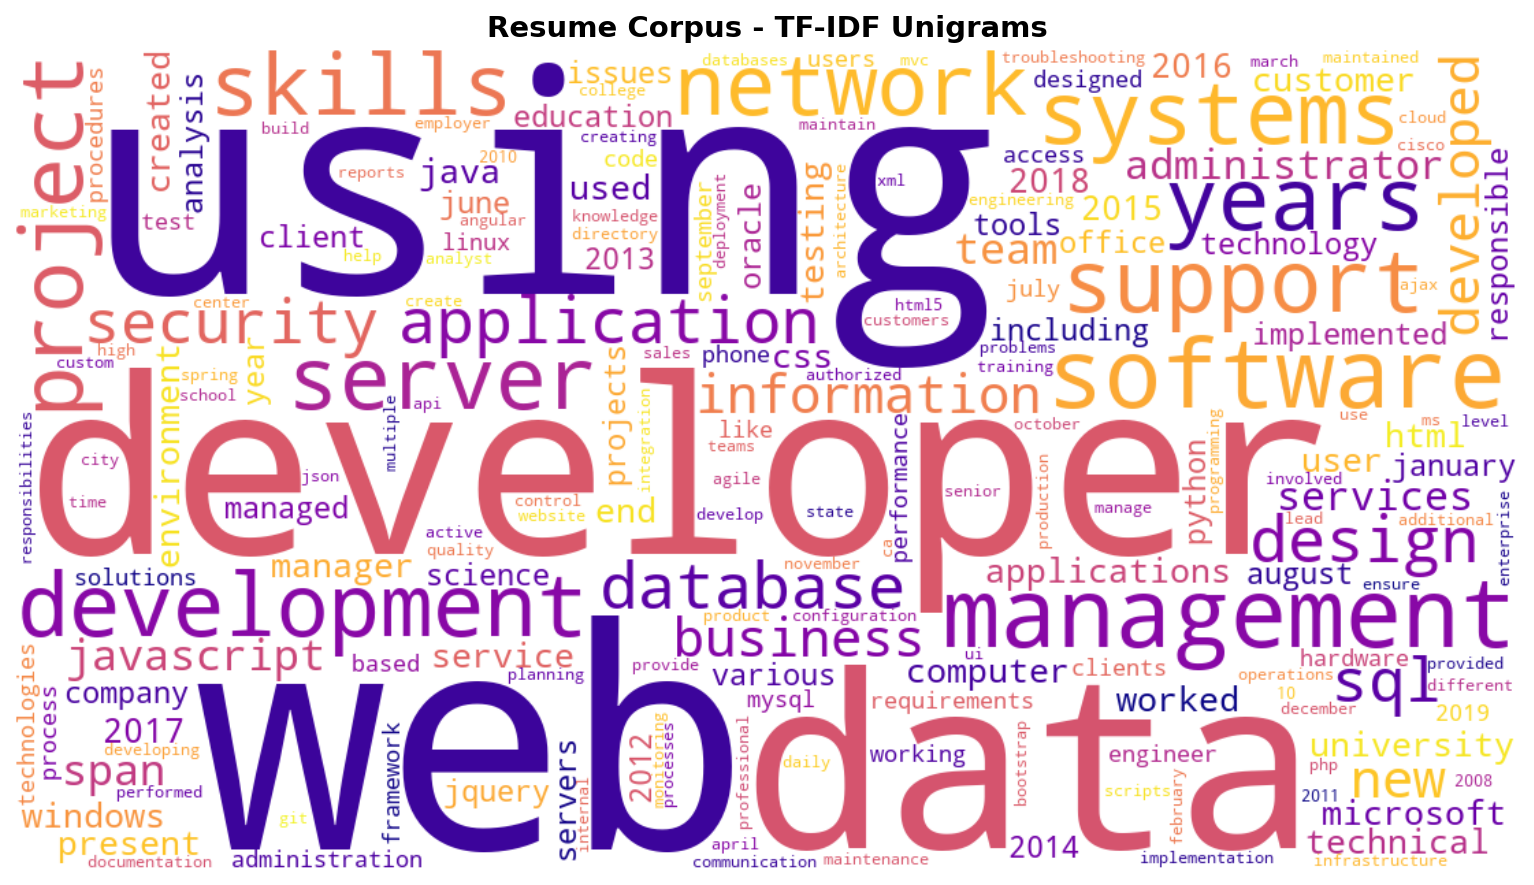

Saved: C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\figures\resumes_wordcloud.png


In [52]:
def plot_wordcloud(freqs, title, colormap="viridis"):
    wc = WordCloud(width=1100, height=600, background_color="white", stopwords=WC_STOPS,
                   prefer_horizontal=0.9, colormap=colormap, random_state=42)
    wc = wc.generate_from_frequencies(freqs)
    plt.figure(figsize=(11,6), dpi=150)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=14, weight="bold")
    out = FIGURES_DIR/'resumes_wordcloud.png'
    plt.tight_layout()
    plt.savefig(out, bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved:', out)
# Resumes cloud
res_texts = df["clean_text_redacted"].astype(str).tolist()
res_freqs = tfidf_unigram_weights(res_texts)
plot_wordcloud(res_freqs, "Resume Corpus - TF-IDF Unigrams", colormap="plasma")

#### EDA Summary

A compact JSON file with key stats and figure/table paths.

In [54]:
summary = {'n_rows': int(len(df))}
if 'n_tokens' in df.columns:
    summary['n_tokens'] = {
        'mean': float(df['n_tokens'].mean()),
        'std': float(df['n_tokens'].std()),
        'min': int(df['n_tokens'].min()),
        'p25': float(df['n_tokens'].quantile(0.25)),
        'median': float(df['n_tokens'].median()),
        'p75': float(df['n_tokens'].quantile(0.75)),
        'max': int(df['n_tokens'].max())
    }

if 'n_chars' in df.columns:
    summary['n_chars'] = {
        'mean': float(df['n_chars'].mean()),
        'std': float(df['n_chars'].std()),
        'min': int(df['n_chars'].min()),
        'p25': float(df['n_chars'].quantile(0.25)),
        'median': float(df['n_chars'].median()),
        'p75': float(df['n_chars'].quantile(0.75)),
        'max': int(df['n_chars'].max())
    }

for flag in ['has_skills', 'has_education', 'has_experience']:
    if flag in df.columns:
        summary[f'frac_{flag}'] = float(df[flag].mean())

# Figures
summary['figures'] = []
for fn in ['eda_tokens_hist.png', 'eda_chars_hist.png', 'eda_section_coverage.png',
           'eda_top_skills.png', 'eda_top_unigrams.png', 'eda_top_bigrams.png']:
    p = FIGURES_DIR/fn
    if p.exists():
        summary['figures'].append(str(p.resolve()))

# CSV refs
for fn in ['eda_top_unigrams.csv', 'eda_top_bigrams.csv', 'eda_shortest_by_tokens.csv', 'eda_longest_by_tokens.csv']:
    p = REPORTS_DIR/fn
    if p.exists():
        summary.setdefault('tables', []).append(str(p.resolve()))

with open(REPORTS_DIR/'eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved:', REPORTS_DIR/'eda_summary.json')
summary

Saved: C:\Users\Keya Barua\Documents\MSC Data Science - Middlesex University\CST 4090\reports\eda_summary.json


{'n_rows': 31647,
 'n_tokens': {'mean': 913.8810629759535,
  'std': 757.922784524955,
  'min': 20,
  'p25': 394.0,
  'median': 673.0,
  'p75': 1155.0,
  'max': 12604},
 'n_chars': {'mean': 6388.6459064050305,
  'std': 5207.118703819349,
  'min': 154,
  'p25': 2780.0,
  'median': 4787.0,
  'p75': 8127.0,
  'max': 83694},
 'frac_has_skills': 0.9139254905678263,
 'frac_has_education': 0.9463772237494865,
 'frac_has_experience': 0.9946598413751698,
 'figures': ['C:\\Users\\Keya Barua\\Documents\\MSC Data Science - Middlesex University\\CST 4090\\figures\\eda_tokens_hist.png',
  'C:\\Users\\Keya Barua\\Documents\\MSC Data Science - Middlesex University\\CST 4090\\figures\\eda_chars_hist.png',
  'C:\\Users\\Keya Barua\\Documents\\MSC Data Science - Middlesex University\\CST 4090\\figures\\eda_section_coverage.png',
  'C:\\Users\\Keya Barua\\Documents\\MSC Data Science - Middlesex University\\CST 4090\\figures\\eda_top_skills.png',
  'C:\\Users\\Keya Barua\\Documents\\MSC Data Science - Middl